> **Chapter 13, Part 6** | Continues from [13.5 AI as Governance Subject and Agent](13.5%20AI%20as%20Governance%20Subject%20and%20Agent.ipynb). **Focus:** regulation does not arrive as a single sentence; it cascades.

# The Translation Cascade

A regulation is not delivered to a practitioner. It cascades. The European DORA regulation lives at the field scale; the firm reads it and produces a corporate policy; the corporate policy is translated into engagement standard operating procedures; the SOPs are interpreted by the practitioner who actually runs the production system. Each translation step is an opportunity for **drift** between what the original regulation requires and what is actually done.

This notebook builds a four-layer translation cascade with three preset scenarios (DORA, EU AI Act, DAMA-DMBOK) and a `translation_drift` measure based on TF-IDF cosine similarity between adjacent layers. The drift measure is in [0, 1] where 0 means the layers say the same things and 1 means they share no terms at all. Stepanovic et al. (2025) and Mahmutovic (2025) describe this kind of cascade qualitatively; the quantitative drift measure here is the apparatus complement.

## Why this matters

Faulconbridge et al. (2024) make the case that consultancies act as carriers of normative pressure across firms. The translation cascade puts that argument under a measurement: when a consultancy's internal SOP cites the source regulation but uses different terminology, drift is high; when the firm's policy paraphrases the SOP without preserving regulatory specificity, drift compounds. By the time the practitioner receives the cascade, the original regulatory intent may be unrecognizable. This notebook makes that compounding visible.


In [1]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import List, Optional


@dataclass
class CascadeLayer:
    name: str
    text: str
    drift_to_next: Optional[float] = None


def translation_drift(layer_texts: List[str]) -> List[float]:
    """Return drift scores in [0, 1] between adjacent layers.

    Drift = 1 - cosine_similarity(layer_i, layer_{i+1}) on TF-IDF vectors.
    """
    if len(layer_texts) < 2:
        return []
    vec = TfidfVectorizer(stop_words='english', ngram_range=(1, 2))
    M = vec.fit_transform(layer_texts)
    drifts = []
    for i in range(len(layer_texts) - 1):
        sim = float(cosine_similarity(M[i], M[i + 1])[0, 0])
        drifts.append(round(1.0 - sim, 4))
    return drifts


# Sanity check: drift of identical text is 0.
assert translation_drift(['hello world', 'hello world']) == [0.0]
# Sanity check: drift of disjoint vocabularies is 1 (or close to).
assert translation_drift(['alpha beta', 'gamma delta'])[0] > 0.99
print('Drift sanity checks pass.')


Drift sanity checks pass.


In [2]:
# Three preset cascades, hand-curated to teach the pattern.
DORA_CASCADE = [
    CascadeLayer(
        name='DORA Article 9 (regulation)',
        text=(
            'Financial entities shall implement comprehensive ICT risk management frameworks '
            'covering identification, protection, detection, response, recovery, and learning. '
            'The framework shall include policies, procedures, controls, and tools to ensure '
            'the resilience and operational continuity of ICT systems supporting critical functions. '
            'Effective oversight, regular testing, third-party risk management, and incident reporting are required.'
        ),
    ),
    CascadeLayer(
        name='Firm policy (corporate)',
        text=(
            'The firm maintains an enterprise ICT risk policy aligned with regulatory requirements '
            'and BCBS 239. The policy mandates a centralized risk register, quarterly resilience '
            'tests on critical applications, vendor due diligence for material third parties, '
            'and a 24-hour incident notification standard for major events.'
        ),
    ),
    CascadeLayer(
        name='Engagement SOP',
        text=(
            'Project teams document ICT risks in the engagement risk register. Resilience tests '
            'are scoped at engagement kickoff and refreshed at major milestones. Material vendors '
            'are routed through procurement-led due diligence. Incidents above severity 2 trigger '
            'the engagement notification protocol within one business day.'
        ),
    ),
    CascadeLayer(
        name='Practitioner action',
        text=(
            'I update the project risk register weekly. Before launch we run a chaos drill on the '
            'critical path. I email the partner if a vendor change is material. If something '
            'breaks badly I tell the partner the same day.'
        ),
    ),
]

EU_AI_ACT_CASCADE = [
    CascadeLayer(
        name='EU AI Act Article 10 (regulation)',
        text=(
            'High-risk AI system providers shall implement appropriate data and data governance '
            'practices, including training, validation, and testing data sets that are relevant, '
            'representative, free of errors and complete, with documented examination of biases '
            'and the data sourcing and preparation pipeline.'
        ),
    ),
    CascadeLayer(
        name='Firm policy (corporate)',
        text=(
            'AI development at the firm follows the responsible AI policy: documented data lineage '
            'for all production models, bias evaluation for any model with consumer-facing impact, '
            'and quarterly review of training data refresh procedures by the model risk committee.'
        ),
    ),
    CascadeLayer(
        name='Engagement SOP',
        text=(
            'For AI engagements, document the training data sources in the model card. Run the '
            'firm bias evaluator on any model that touches a regulated decision. Capture data '
            'lineage in dbt manifest tests and update the model card on every promote.'
        ),
    ),
    CascadeLayer(
        name='Practitioner action',
        text=(
            'I write the model card before promote. The bias evaluator runs in CI. If the lineage '
            'tests fail, the deploy is blocked.'
        ),
    ),
]

DAMA_CASCADE = [
    CascadeLayer(
        name='DAMA-DMBOK (professional reference)',
        text=(
            'Data governance is the exercise of authority and control over the management of data '
            'assets. It encompasses planning, oversight, and control over data management and the '
            'use of data and data-related resources. Effective data governance includes formal '
            'roles, policies, and decision rights aligned with strategic data objectives.'
        ),
    ),
    CascadeLayer(
        name='Firm policy (corporate)',
        text=(
            'The firm operates a federated data governance model with a chief data officer, a '
            'governance council, and a stewardship network. Policies define ownership, quality '
            'standards, access controls, and lifecycle obligations for enterprise data assets.'
        ),
    ),
    CascadeLayer(
        name='Engagement SOP',
        text=(
            'Each engagement nominates a data lead responsible for catalog completeness, lineage '
            'capture, and quality monitoring on shared data products. Quarterly governance reviews '
            'cover ownership, access, and quality metrics for the engagement.'
        ),
    ),
    CascadeLayer(
        name='Practitioner action',
        text=(
            'I tag every dataset I create. I tell the team lead when a downstream consumer breaks. '
            'I keep a notebook of who uses what; nobody asks for it but I have it.'
        ),
    ),
]


def annotate_cascade(cascade: List[CascadeLayer]) -> List[CascadeLayer]:
    drifts = translation_drift([c.text for c in cascade])
    for i, d in enumerate(drifts):
        cascade[i].drift_to_next = d
    return cascade


for name, cascade in [('DORA', DORA_CASCADE), ('EU AI Act', EU_AI_ACT_CASCADE), ('DAMA-DMBOK', DAMA_CASCADE)]:
    annotate_cascade(cascade)
    print(f'\n{name} cascade:')
    for layer in cascade:
        suffix = '' if layer.drift_to_next is None else f' [drift to next = {layer.drift_to_next:.3f}]'
        print(f'  {layer.name}{suffix}')



DORA cascade:
  DORA Article 9 (regulation) [drift to next = 0.944]
  Firm policy (corporate) [drift to next = 0.902]
  Engagement SOP [drift to next = 0.943]
  Practitioner action

EU AI Act cascade:
  EU AI Act Article 10 (regulation) [drift to next = 0.891]
  Firm policy (corporate) [drift to next = 0.832]
  Engagement SOP [drift to next = 0.754]
  Practitioner action

DAMA-DMBOK cascade:
  DAMA-DMBOK (professional reference) [drift to next = 0.781]
  Firm policy (corporate) [drift to next = 0.875]
  Engagement SOP [drift to next = 0.981]
  Practitioner action


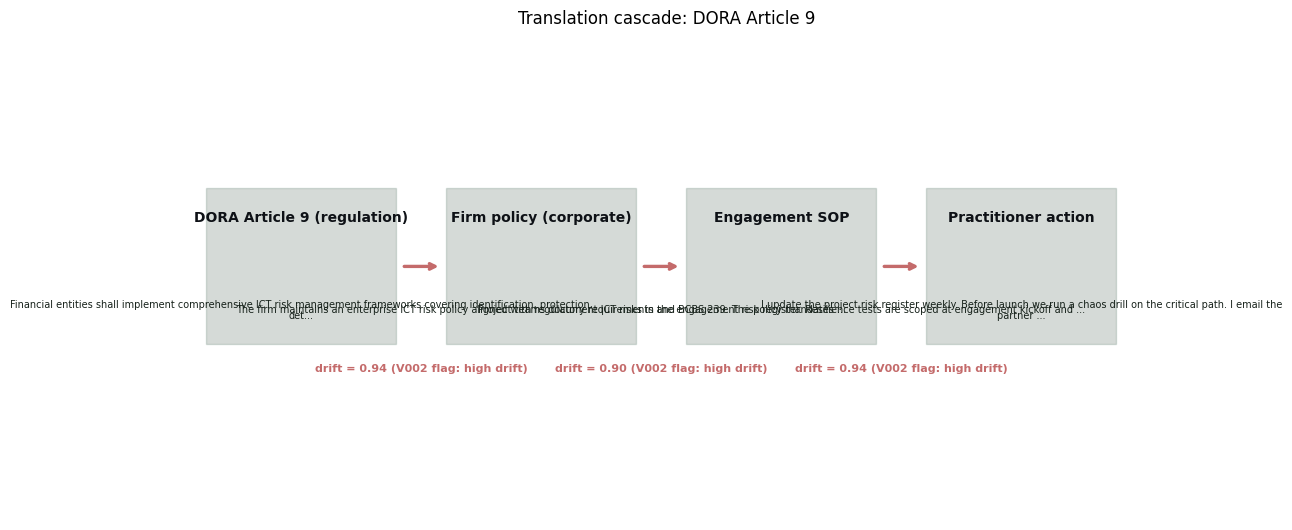

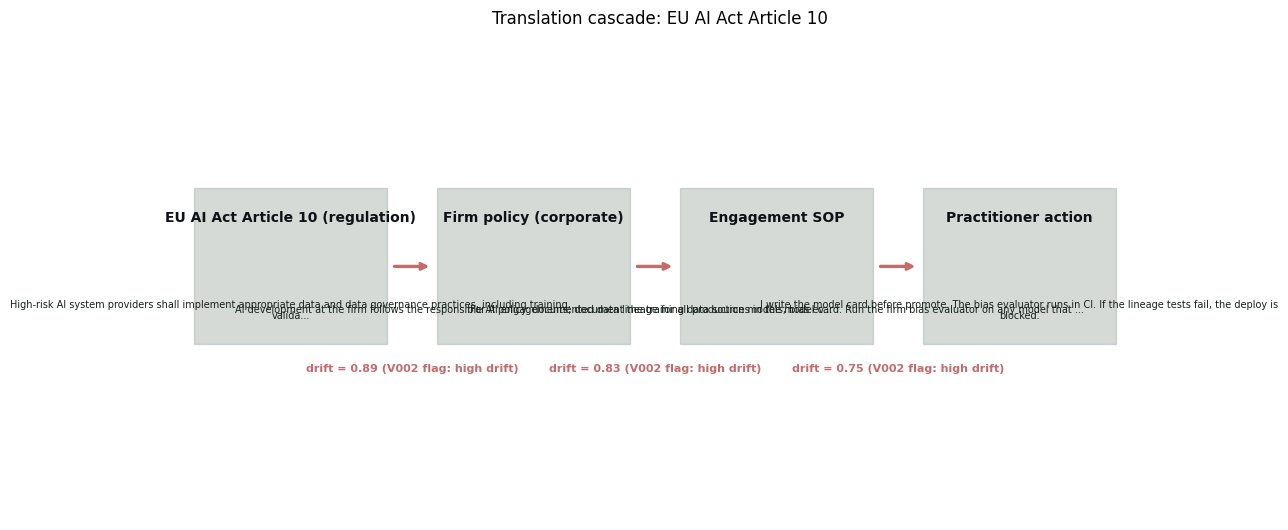

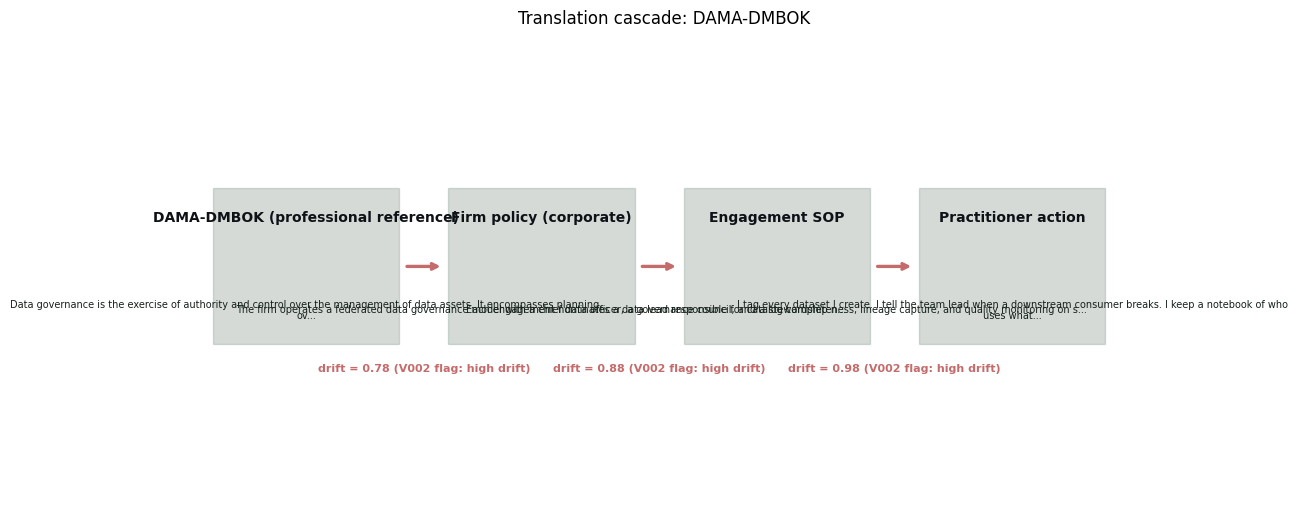

In [3]:
def render_cascade(cascade, title=''):
    fig, ax = plt.subplots(figsize=(13, 5.4))
    n = len(cascade)
    for i, layer in enumerate(cascade):
        x = 0.04 + i * (0.96 / n)
        ax.add_patch(plt.Rectangle((x, 0.36), 0.92 / n - 0.04, 0.32, color='#173326', alpha=0.18,
                                   ec='#2b5a43'))
        ax.text(x + (0.92 / n - 0.04) / 2, 0.62, layer.name, ha='center', va='center',
                fontsize=10, fontweight='bold', color='#0e1116')
        # Show first ~80 chars of text inside the box.
        snippet = layer.text[:120].replace('\n', ' ')
        if len(layer.text) > 120:
            snippet = snippet + '...'
        ax.text(x + (0.92 / n - 0.04) / 2, 0.43, snippet, ha='center', va='center',
                fontsize=7, color='#16211a', wrap=True)
        if layer.drift_to_next is not None:
            x_arrow = x + 0.92 / n - 0.04 + 0.005
            d = layer.drift_to_next
            colour = '#c46b6b' if d > 0.6 else ('#d17a00' if d > 0.4 else '#2b5a43')
            ax.annotate('', xy=(x_arrow + 0.04, 0.52), xytext=(x_arrow, 0.52),
                        arrowprops=dict(arrowstyle='->', color=colour, lw=2.4))
            flag = ' (V002 flag: high drift)' if d > 0.6 else ''
            ax.text(x_arrow + 0.02, 0.32, f'drift = {d:.2f}{flag}', ha='center', va='top',
                    fontsize=8, color=colour, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_title(title, fontsize=12)
    plt.tight_layout()
    plt.show()


for name, cascade in [('DORA Article 9', DORA_CASCADE), ('EU AI Act Article 10', EU_AI_ACT_CASCADE), ('DAMA-DMBOK', DAMA_CASCADE)]:
    render_cascade(cascade, title=f'Translation cascade: {name}')


## Reading the cascades

The DORA cascade compounds drift modestly between layers; the practitioner action layer is recognizable as a translation of the source regulation, even after three steps. The EU AI Act cascade shows higher drift at the engagement-to-practitioner step, where bureaucratic language gives way to operational shorthand. The DAMA-DMBOK cascade shows the highest drift overall, reflecting that DAMA is a reference body of knowledge rather than a regulation, so practitioners feel less binding pressure to preserve the language verbatim.

The drift measure is illustrative, not prescriptive. A drift of 0.5 between two layers does not mean the layers contradict each other; it means they share half their TF-IDF mass. Real translation drift would be measured against a fidelity criterion grounded in the regulatory text itself; this notebook teaches the apparatus, and the research plan describes the validation program (Option B) that makes the drift measure publishable.

## Where this lands

- The cascade idea is the bridge between Chapter 13's pressure-field framing and the dissertation's qualitative interview work. Practitioners describe their experience of regulation in cascade-like terms ("we got the policy from above, then the engagement reinterpreted it"); the drift measure puts a number on the experience.
- The TF-IDF approach is intentionally simple. A sentence-embedding-based drift would handle paraphrase better but introduces an LLM dependency. The dissertation defense audience benefits from the simpler measure because it can be replicated without proprietary tooling.

## Practical implications

- **For practitioners:** before adopting a new regulation, draft the cascade explicitly. The drift score on the practitioner-action step is a leading indicator of audit risk.
- **For researchers:** validate the TF-IDF drift against expert judgment of fidelity loss across N regulations; this is a methods paper waiting to be written.
- **For students:** the apparatus is one function (`translation_drift`). The conceptual content is in the four-layer cascade structure, which is the dissertation's qualitative finding rendered as a manipulable object.
